## 1. Анализ данных, демонстрация навыка работы в библиотеках.
Будем использовать данные Churn Modelling с сайта Kaggle (https://www.kaggle.com/datasets/shubh0799/churn-modelling).
* Просмотр данных


In [16]:
import pandas as pd
import numpy as np

data = pd.read_csv('Churn_Modelling.csv')
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


* Характеристики датасета - описание 

Датасет содержит информацию о клиентах банка и используется для прогнозирования их оттока (прекращение пользования услугами этого банка). Целевая переменная — Exited (бинарная: 1 — клиент ушел, 0 — остался). Данные включают 10,000 записей и 14 столбцов.
Описание признаков:
1. RowNumber — номер строки.
2. CustomerId — уникальный идентификатор клиента.
3. Surname — фамилия клиента.
4. CreditScore — кредитный рейтинг клиента.
5. Geography — страна проживания (категориальный: France, Spain, Germany).
6. Gender — пол клиента (категориальный: Male, Female).
7. Age — возраст клиента.
8. Tenure — количество лет, которые клиент является клиентом банка.
9. Balance — баланс на счете.
10. NumOfProducts — количество продуктов банка, используемых клиентом.
11. HasCrCard — наличие кредитной карты (бинарный: 1 — да, 0 — нет).
12. IsActiveMember — активность клиента (бинарный: 1 — активен, 0 — неактивен).
13. EstimatedSalary — предполагаемая зарплата клиента.
14. Exited — целевая переменная (бинарный: 1 — ушел, 0 — остался).

In [17]:
# Размер датасета
print(data.shape)
print('\n')

# Типы данных
print(data.dtypes)
print('\n')

# Пропущенные значения
print(data.isnull().sum())

(10000, 14)


RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


* Работа с отдельными столбцами или строками
    - простой выбор столбца или строки

In [18]:
# Выбор столбца 'CreditScore'
credit_scores = data['CreditScore']
print("\nПервые 5 значений CreditScore:")
print(credit_scores.head())
print('\n')

# Выбор столбцов 'Gender', 'Age', 'Balance'
subset = data[['Gender', 'Age', 'Balance']]
# Вывод первых 3 строк
print(subset.head(3))
print('\n')

# Выбор строки с индексом 0
first_row = data.iloc[0]
print("Первая строка:")
print(first_row)
print('\n')

# Выбор строк с индексами 1, 5, 10
specific_rows = data.iloc[[1, 5, 10]]
print(specific_rows[['Surname', 'Geography', 'Exited']])
print('\n')

rows_10_to_20 = data.iloc[10:20]
print(rows_10_to_20[['CustomerId', 'Surname', 'CreditScore']])


Первые 5 значений CreditScore:
0    619
1    608
2    502
3    699
4    850
Name: CreditScore, dtype: int64


   Gender  Age    Balance
0  Female   42       0.00
1  Female   41   83807.86
2  Female   42  159660.80


Первая строка:
RowNumber                  1
CustomerId          15634602
Surname             Hargrave
CreditScore              619
Geography             France
Gender                Female
Age                       42
Tenure                     2
Balance                  0.0
NumOfProducts              1
HasCrCard                  1
IsActiveMember             1
EstimatedSalary    101348.88
Exited                     1
Name: 0, dtype: object


   Surname Geography  Exited
1     Hill     Spain       0
5      Chu     Spain       1
10  Bearce    France       0


    CustomerId    Surname  CreditScore
10    15767821     Bearce          528
11    15737173    Andrews          497
12    15632264        Kay          476
13    15691483       Chin          549
14    15600882      Scot

* Использование Numpy для датасета

In [19]:
# Преобразование столбца 'Age' в массив numpy
ages_np = np.array(data['Age'])
print("\nСредний возраст (numpy):", np.mean(ages_np))
print("Максимальный возраст (numpy):", np.max(ages_np))


Средний возраст (numpy): 38.9218
Максимальный возраст (numpy): 92


* Использование SciPy для датасета

In [93]:
from scipy import stats

# Расчет моды для 'NumOfProducts'
mode_result = stats.mode(data['NumOfProducts'])
print("\nМода для NumOfProducts:", mode_result.mode)


Мода для NumOfProducts: 1


* Использование метода tolist()

In [32]:
# Преобразование столбца 'Geography' в список
geography_list = data['Geography'].tolist()
print("\nПервые 5 стран из списка:")
print(geography_list[:5])


Первые 5 стран из списка:
['France', 'Spain', 'France', 'France', 'Spain']


* Применение циклов для любого вида анализа или преобразований

In [33]:
# Подсчет клиентов по странам с использованием цикла
countries = data['Geography'].unique()
country_counts = {}

for country in countries:
    count = len(data[data['Geography'] == country])
    country_counts[country] = count

print("\nКоличество клиентов по странам:")
print(country_counts)


Количество клиентов по странам:
{'France': 5014, 'Spain': 2477, 'Germany': 2509}


* Добавление новой строки

In [38]:
# Добавление столбца 'BalanceToSalaryRatio' с защитой от деления на ноль
data['BalanceToSalaryRatio'] = np.where(
    data['EstimatedSalary'] != 0,
    data['Balance'] / data['EstimatedSalary'],
    0  # значение по умолчанию при делении на ноль
)

# Создание новой строки как DataFrame
new_row = pd.DataFrame({
    'RowNumber': [1001],
    'CustomerId': [15634603],
    'Surname': ['Smith'],
    'CreditScore': [700],
    'Geography': ['France'],
    'Gender': ['Male'],
    'Age': [30],
    'Tenure': [2],
    'Balance': [0],
    'NumOfProducts': [1],
    'HasCrCard': [1],
    'IsActiveMember': [1],
    'EstimatedSalary': [100000],
    'Exited': [0],
    'BalanceToSalaryRatio': [0]
})

# Добавление строки с помощью concat
data = pd.concat([data, new_row], ignore_index=True)

print("\nДобавлена новая строка:")
print(data.tail(1))


Добавлена новая строка:
       RowNumber  CustomerId Surname  CreditScore Geography Gender  Age  \
10000       1001    15634603   Smith          700    France   Male   30   

       Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  \
10000       2      0.0              1          1               1   

       EstimatedSalary  Exited  BalanceToSalaryRatio  
10000         100000.0       0                   0.0  


* Удаление столбца

In [ ]:
# Удаление столбца 'RowNumber'
data.drop('RowNumber', axis=1, inplace=True)

# Удаление строк с Age > 80
df = data[data['Age'] <= 80]

data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceToSalaryRatio
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055


* Поиск уникальных значений

In [44]:
# Уникальные значения в столбце 'Geography'
unique_countries = data['Geography'].unique()
print("\nУникальные страны:")
print(unique_countries)

# Уникальные значения в столбце 'NumOfProducts'
unique_products = data['NumOfProducts'].unique()
print("\nУникальные значения NumOfProducts:")
print(unique_products)


Уникальные страны:
['France' 'Spain' 'Germany']

Уникальные значения NumOfProducts:
[1 3 2 4]


* Группировка данных для анализа Pandas 

In [45]:
# Средний возраст по странам и полу
grouped_data = data.groupby(['Geography', 'Gender'])['Age'].mean()
print("\nСредний возраст по странам и полу:")
print(grouped_data)


Средний возраст по странам и полу:
Geography  Gender
France     Female    38.676862
           Male      38.238822
Germany    Female    40.154233
           Male      39.325971
Spain      Female    39.199265
           Male      38.613554
Name: Age, dtype: float64


* Сводные таблицы

In [47]:
# Сводная таблица: средний баланс по странам и полу
pivot_table = pd.pivot_table(data, values='Balance', index='Geography', columns='Gender', aggfunc='mean')
print("\nСводная таблица (средний баланс):")
print(pivot_table)


Сводная таблица (средний баланс):
Gender            Female           Male
Geography                              
France      60417.413050   63502.483719
Germany    119145.966471  120277.300274
Spain       59862.092534   63398.509906


* Cортировка данных

In [48]:
# Сортировка по возрасту (по убыванию)
sorted_df = data.sort_values('Age', ascending=False)
print("\nТоп-5 самых старших клиентов:")
print(sorted_df[['Surname', 'Age']].head())


Топ-5 самых старших клиентов:
         Surname  Age
9490   Yermakova   80
3994   Siciliano   80
310   Pokrovskii   80
4832      Iheatu   79
5068        Chen   79


* Фильтрация 

In [49]:
# Фильтрация активных клиентов с высокой зарплатой
filtered_df = data[(data['IsActiveMember'] == 1) & (data['EstimatedSalary'] > 150000)]
print("\nАктивные клиенты с зарплатой > 150,000:")
print(filtered_df[['Surname', 'EstimatedSalary']].head())


Активные клиенты с зарплатой > 150,000:
          Surname  EstimatedSalary
20       McDonald        170886.17
24            Yen        187616.16
26          Young        170041.95
31  Odinakachukwu        156731.91
39        Cameron        178074.04


* Применение функций к столбцам 

In [50]:
# Функция для категоризации возраста
def age_category(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle-aged'
    else:
        return 'Senior'

# Применение функции к столбцу 'Age'
data['AgeCategory'] = data['Age'].apply(age_category)
print("\nКатегории возраста:")
print(data[['Age', 'AgeCategory']].head())


Категории возраста:
   Age  AgeCategory
0   42  Middle-aged
1   41  Middle-aged
2   42  Middle-aged
3   39  Middle-aged
4   43  Middle-aged


* Очистка данных

In [51]:
# Заполнение пропусков (если есть)
data.fillna({'Balance': 0}, inplace=True)

# Удаление дубликатов
data.drop_duplicates(inplace=True)

print("\nДатасет после очистки:")
print(data.info())


Датасет после очистки:
<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 0 to 10000
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerId            9989 non-null   int64  
 1   Surname               9989 non-null   object 
 2   CreditScore           9989 non-null   int64  
 3   Geography             9989 non-null   object 
 4   Gender                9989 non-null   object 
 5   Age                   9989 non-null   int64  
 6   Tenure                9989 non-null   int64  
 7   Balance               9989 non-null   float64
 8   NumOfProducts         9989 non-null   int64  
 9   HasCrCard             9989 non-null   int64  
 10  IsActiveMember        9989 non-null   int64  
 11  EstimatedSalary       9989 non-null   float64
 12  Exited                9989 non-null   int64  
 13  BalanceToSalaryRatio  9989 non-null   float64
 14  AgeCategory           9989 non-null   object 
dtypes

* Построение графиков 

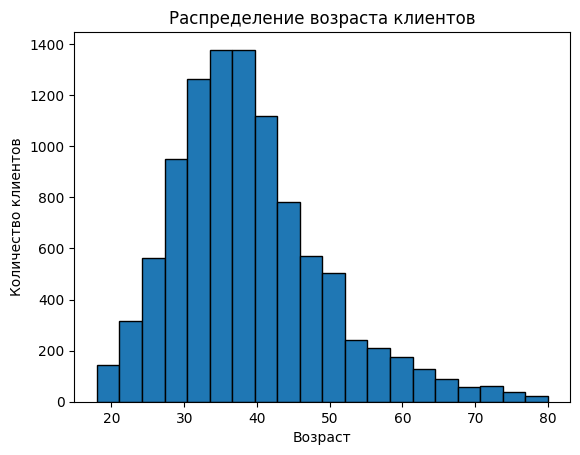

In [53]:
import matplotlib.pyplot as plt
# Гистограмма возрастов
plt.hist(data['Age'], bins=20, edgecolor='black')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.show()

In [88]:
import plotly.express as px

fig = px.pie(data, names='Geography', title='Распределение клиентов по странам')
fig.show(renderer='browser')

gio: http://127.0.0.1:34497: Operation not supported


## 2. Подготовка и предобработка данных

Построим тепловую карту корреляции между числовыми признаками (int)

Text(0.5, 1.0, 'Correlation of Features')

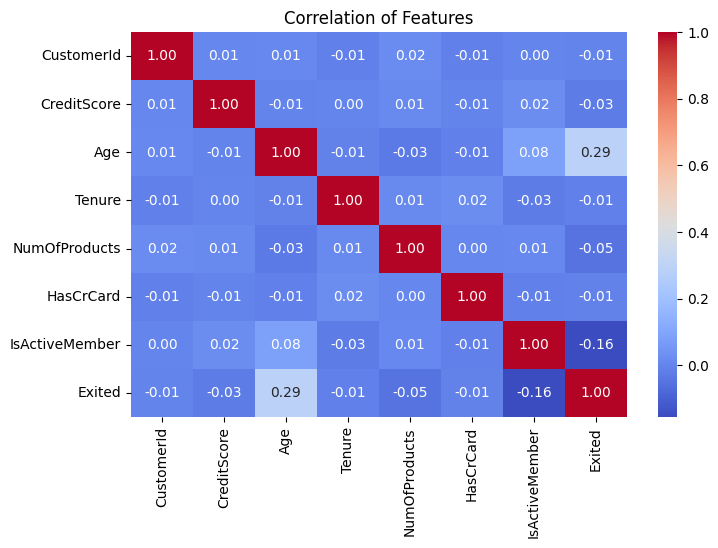

In [68]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(data.select_dtypes(include=['int']).corr(),cmap='coolwarm', fmt=".2f",annot=True)
plt.title('Correlation of Features')

Разделение данных на признаки (X) и целевую переменную (y)

In [72]:
x=data.drop(['Exited'],axis=1)
y=data['Exited']

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =  train_test_split(x,y,test_size=0.2,random_state=42)

Кодируем категориальные признаки (Gender, Geography) в бинарные столбцы

In [74]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded_train = encoder.fit_transform(x_train[['Gender','Geography']].reset_index(drop=True))
encoded_test = encoder.transform(x_test[['Gender','Geography']].reset_index(drop=True))

encoded_df_train = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(['Gender','Geography']))
encoded_df_test = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(['Gender','Geography']))

x_train = pd.concat([x_train.reset_index(drop=True), encoded_df_train], axis=1)
x_test = pd.concat([x_test.reset_index(drop=True), encoded_df_test], axis=1)

x_train.drop(['Gender','Geography'],axis=1,inplace=True)
x_test.drop(['Gender','Geography'],axis=1,inplace=True)

Преобразуем порядковые признаки (например, Tenure — срок клиента) в числа (0, 1, 2, ...)

In [76]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

ordinal_features = ['Tenure','NumOfProducts']

for i in ordinal_features:
    x_train[i] = encoder.fit_transform(x_train[i].reset_index(drop=True))
    x_test[i] = encoder.transform(x_test[i].reset_index(drop=True))

Визуализируем распределение CreditScore (кредитный рейтинг)

<Axes: xlabel='CreditScore', ylabel='Count'>

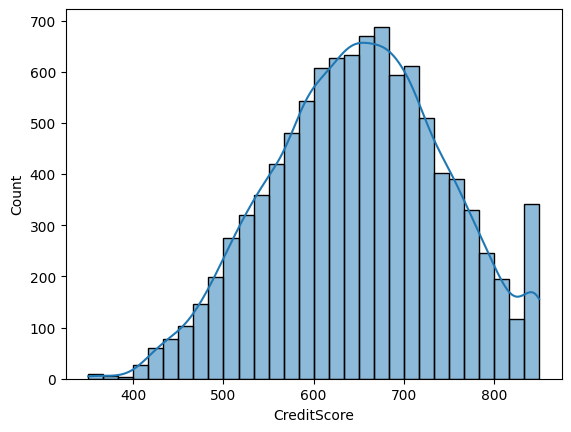

In [80]:
sns.histplot(data['CreditScore'], kde=True, bins=30)

Визуализируем распределение Balance (счет денежных средств в банке)

<Axes: xlabel='Balance', ylabel='Count'>

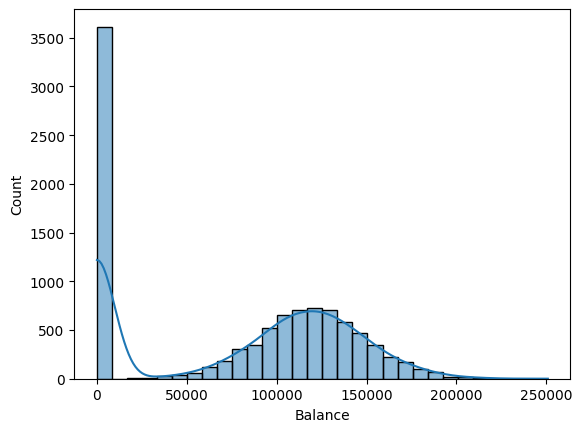

In [81]:
sns.histplot(data['Balance'], kde=True, bins=30)

Масштабируем числовые признаки, стандартизируем признаки

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[['Balance','EstimatedSalary']] = scaler.fit_transform(x_train[['Balance','EstimatedSalary']].reset_index(drop=True))
x_test[['Balance','EstimatedSalary']] = scaler.transform(x_test[['Balance','EstimatedSalary']].reset_index(drop=True))

# подсчет процентного соотношения классов в целевой переменной
y_train.value_counts() / y_train.shape[0] *100

Exited
0    79.727193
1    20.272807
Name: count, dtype: float64

## 3. Построение модели и проверка качества модели c помощью метрик качества. Использование кросс-валидации.

Результаты кросс-валидации (ROC-AUC):
Среднее: 0.857 ± 0.016

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1582
           1       0.76      0.40      0.52       416

    accuracy                           0.85      1998
   macro avg       0.81      0.68      0.72      1998
weighted avg       0.84      0.85      0.83      1998


ROC-AUC Score: 0.818
Accuracy: 0.848


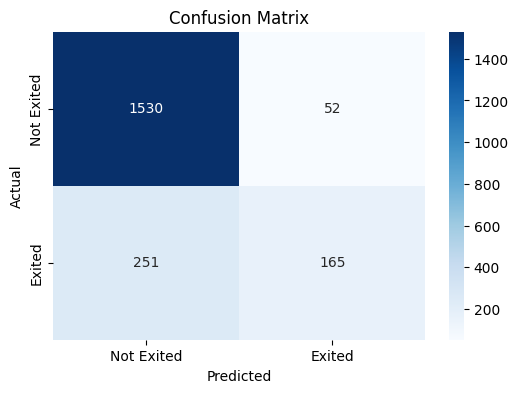

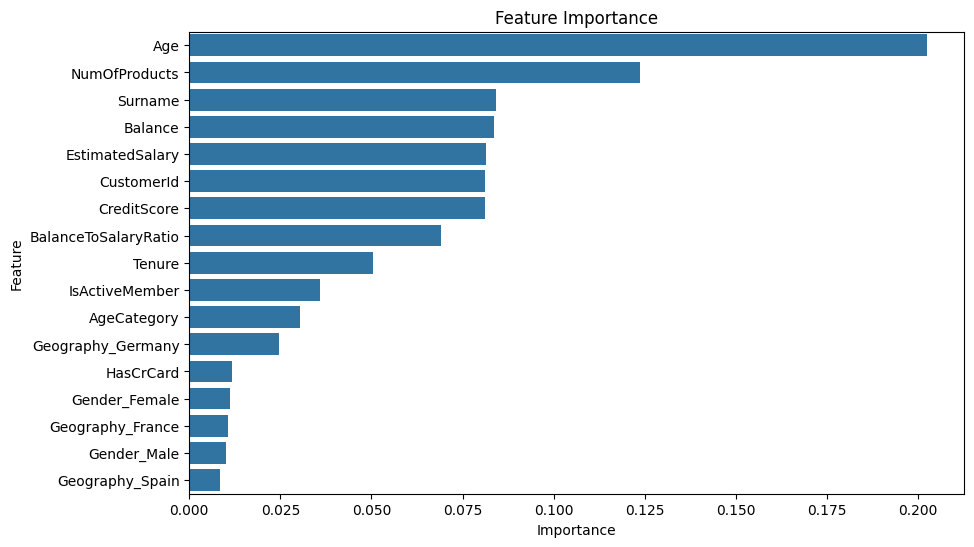

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score, KFold

def preprocess_data(df):
    for col in df.columns:
        if df[col].dtype == 'object':  # Если столбец содержит строки
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))  # Преобразуем строки в числа
    return df

x_train = preprocess_data(x_train.copy())
x_test = preprocess_data(x_test.copy())

# Инициализация модели
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Кросс-валидация (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, x_train, y_train, cv=kf, scoring='roc_auc')

print("Результаты кросс-валидации (ROC-AUC):")
print(f"Среднее: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Обучение модели на всем тренировочном наборе
model.fit(x_train, y_train)

# Предсказания на тестовых данных
y_pred = model.predict(x_test)
y_proba = model.predict_proba(x_test)[:, 1]

# Метрики качества
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Exited', 'Exited'], 
            yticklabels=['Not Exited', 'Exited'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()